# Quantum Optics - Homework 3 - Rabi oscillations with detuning

## Jan Chelmecki

$$
P_1(\Delta, t) = \frac{\Omega^2}{\Omega^2+\Delta^2} \; \frac{1+\cos(2\pi*\sqrt{\Omega^2+\Delta^2} \; t)}{2}
$$

In [55]:
import numpy as np
import matplotlib.pyplot as plt

In [56]:
2*np.pi/np.sqrt(5.44**2 + 0.074**2)

1.154890453586579

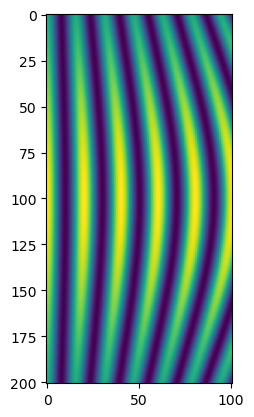

In [57]:
t = np.linspace(0,40,101)/1000
d = np.linspace(-100,100,201)
T, Delta = np.meshgrid(t,d)

Omega = 124 #Mhz
P = Omega**2 / (Omega**2 + Delta**2) * (1+ np.cos(2*np.pi*np.sqrt(Omega**2 + Delta**2)*T) ) /2
plt.imshow(P)

In [59]:
from qutip import *

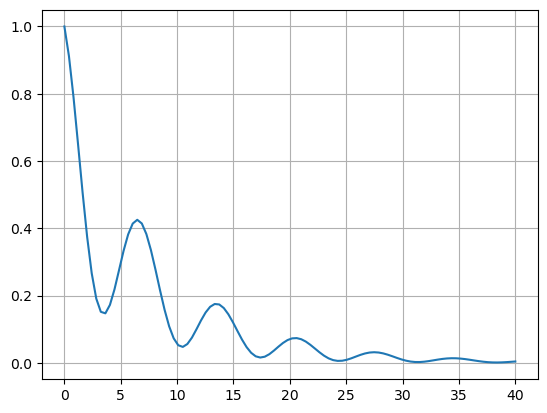

In [142]:
omega = 124 *2*np.pi/1000 # GHz
delta = 72 *2*np.pi/1000 #GHz
fr = 6175 *2*np.pi/1000 # GHz
fq = fr + delta



N = 5
am = tensor(destroy(N), qeye(2))
ap = tensor(destroy(N).dag(), qeye(2))
sm = tensor(qeye(N), destroy(2))
sp = tensor(qeye(N), destroy(2).dag())
sz = tensor(qeye(N),sigmaz())

# JC Hamiltonian
H = -fq/2 * sz + fr * ap*am + omega/2 * (am*sp + ap*sm)
psi0 = tensor(basis(N,0), basis(2,1)) # resonator in g.s., qubit excited

# Lindblad operators
T1q = 6; T1r = 17; Tphiq = 100; Tphir = 100 # ns
L1q = 1/np.sqrt(T1q) * sm
Lphiq = 1/np.sqrt(Tphiq)*tensor(qeye(5), destroy(2).dag()*destroy(2))
L1r = 1/np.sqrt(T1r) * am
Lphir = 1/np.sqrt(Tphir)*tensor(destroy(N).dag()*destroy(N), qeye(2))


times = np.linspace(0.0, 40.0, 100)
result = mesolve(H, psi0, times, [L1q, Lphiq, L1r, Lphir], [sz], options=Options(nsteps=10000) )
plt.plot(times, (1-result.expect[0])/2)
plt.grid()

In [195]:
omega = 124 *2*np.pi/1000 # GHz
Delta = 2*np.pi/1000 * np.linspace(-150, 150, 100) #GHz
fr = 6175 *2*np.pi/1000 # GHz
times = np.linspace(0.0, 40.0, 200)

N = 5
am = tensor(destroy(N), qeye(2))
ap = tensor(destroy(N).dag(), qeye(2))
sm = tensor(qeye(N), destroy(2))
sp = tensor(qeye(N), destroy(2).dag())
sz = tensor(qeye(N),sigmaz())
# Lindblad operators
T1q = 6; T1r = 17; Tphiq = 100; Tphir = 100 # ns
L1q = 1/np.sqrt(T1q) * sm
Lphiq = 1/np.sqrt(Tphiq)*tensor(qeye(5), destroy(2).dag()*destroy(2))
L1r = 1/np.sqrt(T1r) * am
Lphir = 1/np.sqrt(Tphir)*tensor(destroy(N).dag()*destroy(N), qeye(2))
P1 = np.zeros((Delta.size, times.size))

for i in range(Delta.size):
    delta = Delta[i]
    fq = fr + delta
    # JC Hamiltonian
    H = -fq/2 * sz + fr * ap*am + omega/2 * (am*sp + ap*sm)
    psi0 = tensor(basis(N,0), basis(2,1)) # resonator in g.s., qubit excited
    result = mesolve(H, psi0, times, [L1q, Lphiq, L1r, Lphir], [sz], options=Options(nsteps=10000) )
    P1[i,:] = (1-result.expect[0])/2

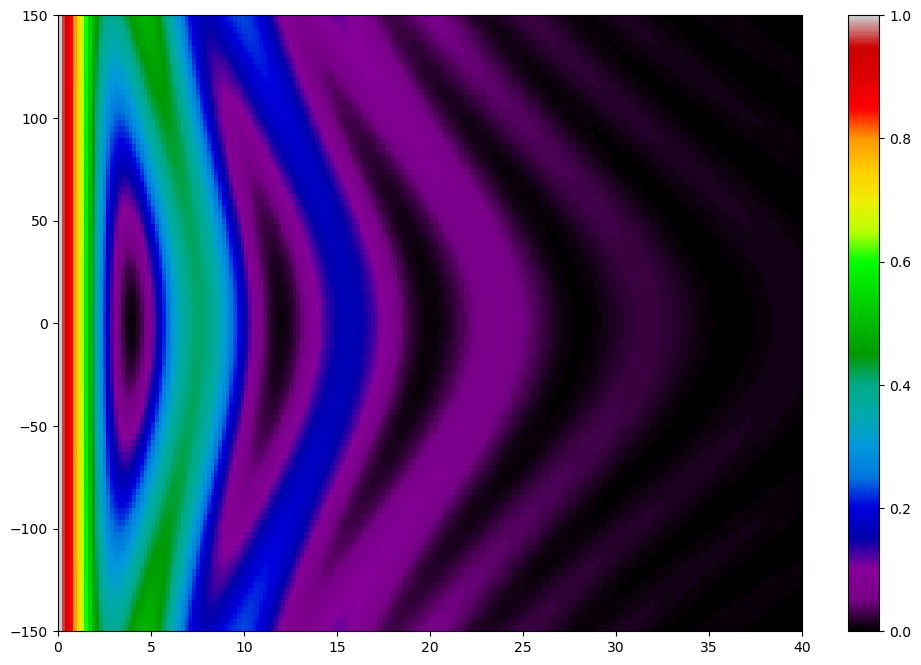

In [196]:
fig, ax = plt.subplots(figsize=(12, 8))
im = ax.imshow(P1, cmap ='nipy_spectral', vmin = 0, vmax = 1, 
				extent =[times.min(), times.max(), 1000/(2*np.pi)*Delta.min(), 1000/(2*np.pi)*Delta.max()], 
					interpolation ='nearest', origin ='lower', aspect='auto')  
plt.colorbar(im)

AttributeError: AxesImage.set() got an unexpected keyword argument 'x'

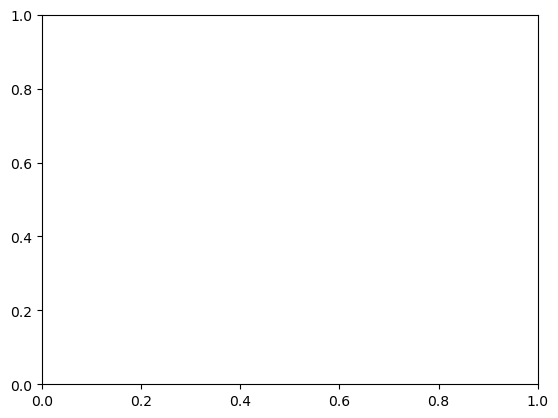

In [147]:
plt.imshow(P1,x = times, y = Delta)

In [118]:
ap

Quantum object: dims=[[5], [5]], shape=(5, 5), type='oper', dtype=Dia, isherm=False
Qobj data =
[[0.         0.         0.         0.         0.        ]
 [1.         0.         0.         0.         0.        ]
 [0.         1.41421356 0.         0.         0.        ]
 [0.         0.         1.73205081 0.         0.        ]
 [0.         0.         0.         2.         0.        ]]

/home/janch/anaconda3/lib/python3.11/site-packages/qutip/solver/solver_base.py:576: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(


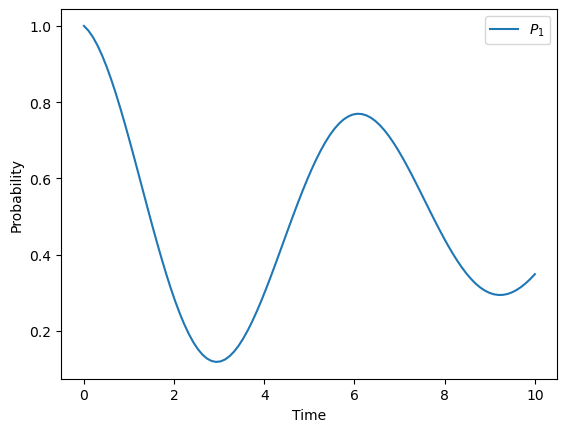

In [ ]:
omega = 1.0
delta = 0.0

H = 1/2 * (omega*sigmax() - delta*sigmaz())

a = destroy(2)
T1q = 6; T1r = 17; Tphiq = 100; Tphir = 100 # ns
L1q = np.sqrt(1/T1q)*a
Tphiq = 10
Lphiq = np.sqrt(1/Tphiq)*a.dag()*a

psi0 = basis(2, 1) #excited state

times = np.linspace(0.0, 10.0, 100)

result = mesolve(H, psi0, times, [L1q, Lphiq], [sigmaz()])

fig, ax = plt.subplots()

P1 = (1 - result.expect[0] ) /2
ax.plot(result.times, P1, label = "$P_1$")

ax.set_xlabel('Time');
ax.set_ylabel('Probability')
ax.legend()
plt.show()

In [72]:
result = mesolve(H, psi0, times, [], [])
result

/home/janch/anaconda3/lib/python3.11/site-packages/qutip/solver/solver_base.py:576: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(


<Result
  Solver: sesolve
  Solver stats:
    method: 'scipy zvode adams'
    init time: 7.748603820800781e-05
    preparation time: 0.00012087821960449219
    run time: 0.01673150062561035
    solver: 'Schrodinger Evolution'
  Time interval: [0.0, 10.0] (100 steps)
  Number of e_ops: 0
  States saved.
>

In [65]:
result.expect

[array([ 1.        ,  0.99800685,  0.99203536,  0.98210933,  0.96826832,
         0.95056751,  0.92907746,  0.90388383,  0.87508706,  0.84280193,
         0.80715715,  0.76829481,  0.72636982,  0.6815493 ,  0.63401194,
         0.58394721,  0.5315547 ,  0.47704322,  0.42063009,  0.36254023,
         0.30300514,  0.24226222,  0.18055353,  0.11812511,  0.05522582,
        -0.00789365, -0.0709816 , -0.13378664, -0.19605834, -0.25754845,
        -0.31801191, -0.37720768, -0.43489979, -0.49085827, -0.54486006,
        -0.59668987, -0.6461411 , -0.69301662, -0.73712958, -0.77830413,
        -0.81637614, -0.85119382, -0.8826184 , -0.91052458, -0.93480113,
        -0.95535128, -0.9720931 , -0.98495987, -0.9939003 , -0.99887875,
        -0.99987537, -0.9968862 , -0.98992315, -0.97901397, -0.96420214,
        -0.94554671, -0.92312204, -0.89701752, -0.8673372 , -0.83419943,
        -0.79773629, -0.75809314, -0.71542799, -0.66991094, -0.62172342,
        -0.57105752, -0.5181152 , -0.46310752, -0.4